# Canonical Engine Parity: VectorBT OSS

**Docker image**: `ml4t`

The earlier Chapter 16 parity notebooks established two stronger results:

- `15_lean_engine_parity`: LEAN matches `ml4t-backtest[lean]` on the canonical benchmark
- `17_backtrader_zipline_engine_parity`: Backtrader and Zipline now match the same benchmark

VectorBT OSS is different. The canonical benchmark reaches **exact terminal-value
parity** but still keeps a small **trade-count residual**. That is still useful
to readers because it shows the distinction between:

- matching the economic outcome
- matching the exact order decomposition

**Learning Objectives**:
- Inspect the canonical VectorBT OSS parity benchmark used by `ml4t-backtest`
- Compare trade-gap, value-gap, and runtime between VectorBT OSS and `ml4t-backtest`
- Understand why exact terminal-value parity can coexist with a small trade residual
- Re-run the benchmark locally when `vectorbt` is installed

**Book Reference**: Chapter 16, Section 16.3 (Vectorized and Event-Driven Backtesting)

**Prerequisites**: `07_engine_divergence_anatomy` and `17_backtrader_zipline_engine_parity`

## Setup

In [1]:
"""Canonical VectorBT OSS parity benchmark."""

import importlib.util
import json
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import ml4t.backtest as ml4t_backtest_pkg
import polars as pl

from utils.paths import get_chapter_dir, get_output_dir
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides after this cell
RUN_LIVE = False
SCENARIO_ID = "multi_250_20yr"
REAL_DATA_PATH = ""

In [3]:
OUTPUT_DIR = get_output_dir(16, "vectorbt_engine_parity")
CACHED_ARTIFACT_PATH = get_chapter_dir(16) / "resources" / "vectorbt_parity_results.json"
LIVE_ARTIFACT_PATH = OUTPUT_DIR / "vectorbt_parity_results_live.json"

## 1. Source of Truth

This notebook uses the same validation source of truth as the other external
engine notebooks: `ml4t-backtest/validation/benchmark_suite.py`.

The benchmark is the canonical target-share daily ranking strategy on real
market data:

- 250 US equities
- 20 years of daily bars
- top-25 / bottom-25 long-short portfolio
- `ml4t.backtest[vectorbt_strict]` compared against VectorBT OSS

In [4]:
def resolve_backtest_repo() -> Path | None:
    """Resolve the sibling ml4t-backtest repository root.

    Returns None when the validation harness is not available (e.g. CI),
    which disables the live rerun path but lets the cached artifact work.
    """
    package_path = Path(ml4t_backtest_pkg.__file__).resolve()
    for parent in package_path.parents:
        if (parent / "validation" / "benchmark_suite.py").exists():
            return parent

    fallback = Path.home() / "ml4t" / "libraries" / "ml4t-backtest"
    if (fallback / "validation" / "benchmark_suite.py").exists():
        return fallback

    return None

`find_real_data_path` resolves the parquet used by the VectorBT comparison
benchmark, checking the explicit override then a fixed list of fallback
locations before giving up.

In [5]:
def find_real_data_path(explicit_path: str) -> Path | None:
    """Locate the real daily equity parquet used by the benchmark harness."""
    candidates: list[Path] = []
    if explicit_path:
        candidates.append(Path(explicit_path).expanduser())

    candidates.append(
        Path.home() / "Dropbox" / "ml4t" / "data" / "equities" / "us_equities.parquet"
    )

    for path in candidates:
        if path.exists():
            return path
    return None

In [6]:
BACKTEST_REPO = resolve_backtest_repo()
BENCHMARK_SUITE = BACKTEST_REPO / "validation" / "benchmark_suite.py" if BACKTEST_REPO else None
REAL_DATA_FILE = find_real_data_path(REAL_DATA_PATH)

print(f"Backtest repo:   {BACKTEST_REPO or 'not found (cached artifact only)'}")
print(f"Benchmark suite: {BENCHMARK_SUITE or 'not found'}")
print(f"Real data:       {REAL_DATA_FILE if REAL_DATA_FILE else 'not found'}")

Backtest repo:   ~/ml4t/libraries/ml4t-backtest
Benchmark suite: ~/ml4t/libraries/ml4t-backtest/validation/benchmark_suite.py
Real data:       not found


## 2. Runtime Prerequisites

The cached artifact path should always work. A live rerun requires:

- the benchmark harness
- the real-data parquet
- `vectorbt`

Unlike LEAN, VectorBT OSS does not need an external workspace or Docker layer.

In [7]:
def check_live_prerequisites() -> pl.DataFrame:
    """Return a checklist for the optional live VectorBT rerun."""
    rows = [
        {
            "requirement": "benchmark_suite.py",
            "ready": BENCHMARK_SUITE is not None and BENCHMARK_SUITE.exists(),
            "detail": BENCHMARK_SUITE.as_posix() if BENCHMARK_SUITE else "not found",
        },
        {
            "requirement": "real daily parquet",
            "ready": REAL_DATA_FILE is not None,
            "detail": REAL_DATA_FILE.as_posix() if REAL_DATA_FILE else "not found",
        },
        {
            "requirement": "vectorbt",
            "ready": importlib.util.find_spec("vectorbt") is not None,
            "detail": "importable" if importlib.util.find_spec("vectorbt") else "missing",
        },
    ]
    return pl.DataFrame(rows)


prereq_df = check_live_prerequisites()
prereq_df

requirement,ready,detail
str,bool,str
"""benchmark_suite.py""",true,"""~/ml4t/libraries/ml…"
"""real daily parquet""",false,"""not found"""
"""vectorbt""",true,"""importable"""


## 3. Load the Cached Parity Snapshot

The committed artifact captures the latest live canonical benchmark rerun.
The current result is important because it shows a narrow but real distinction:

- trade-count parity is not exact
- final-value parity is exact to floating-point noise

In [8]:
def load_parity_artifact(path: Path) -> dict:
    """Load a cached or live parity artifact."""
    return json.loads(path.read_text(encoding="utf-8"))


payload = load_parity_artifact(CACHED_ARTIFACT_PATH)
payload["artifact_source"], payload["scenario_label"]

('benchmark_suite.py real-data rerun (250 US equities x 20yr daily, 1998-2018)',
 '250 assets, 20 years daily')

## 4. Optional Live Rerun

When `RUN_LIVE = True`, the notebook reruns the canonical benchmark for:

- `ml4t-vbt-strict`
- `vbt-oss`

The benchmark calls use `--cache-mode refresh` so the real-data cache is
regenerated under the current Python/NumPy environment if necessary.

In [9]:
def run_framework_benchmark(
    framework: str, scenario_id: str, output_path: Path, real_data_path: Path
) -> dict:
    """Run one benchmark-suite framework and return its single result row."""
    cmd = [
        sys.executable,
        str(BENCHMARK_SUITE),
        "--framework",
        framework,
        "--scenario",
        scenario_id,
        "--data-source",
        "real",
        "--real-data-path",
        str(real_data_path),
        "--cache-mode",
        "refresh",
        "--output-json",
        str(output_path),
    ]
    subprocess.run(cmd, check=True, cwd=str(BACKTEST_REPO))
    report = json.loads(output_path.read_text(encoding="utf-8"))
    return report["results"][0]

`build_live_payload` assembles the parity-comparison row from two live
benchmark results — ml4t-backtest (strict VectorBT profile) and VectorBT
OSS — and computes trade-gap, value-gap, and runtime-speedup metrics
expressed as fractions (the prose displays them in bps with explicit
`× 10_000` derivations).

In [10]:
def build_live_payload(ml4t_result: dict, vbt_result: dict, scenario_id: str) -> dict:
    """Build the notebook payload from two live benchmark results."""
    reference_trades = max(int(vbt_result["num_trades"]), 1)
    reference_value = max(abs(float(vbt_result["final_value"])), 1.0)
    runtime_speedup = (
        float(vbt_result["runtime_sec"]) / float(ml4t_result["runtime_sec"])
        if ml4t_result["runtime_sec"] > 0
        else None
    )
    final_value_gap = float(abs(ml4t_result["final_value"] - vbt_result["final_value"]))

    return {
        "artifact_source": "live benchmark_suite.py rerun",
        "scenario_id": scenario_id,
        "scenario_label": ml4t_result["scenario"],
        "data_source": "real",
        "cached": False,
        "limitations": [
            "These results cover the canonical target-share benchmark, not the Chapter 16 case-study adapters.",
            "VectorBT OSS matches terminal value to floating-point noise on the current benchmark surface.",
            "A small residual trade gap remains, so this is economic parity rather than exact order decomposition parity.",
        ],
        "results": [
            {
                "engine_id": "vectorbt",
                "engine_label": "VectorBT OSS",
                "profile": "vectorbt_strict",
                "status": "production",
                "ml4t_framework_id": "ml4t-vbt-strict",
                "reference_framework_id": "vbt-oss",
                "ml4t_num_trades": int(ml4t_result["num_trades"]),
                "reference_num_trades": int(vbt_result["num_trades"]),
                "trade_gap": int(ml4t_result["num_trades"] - vbt_result["num_trades"]),
                "trade_gap_pct": float(
                    (ml4t_result["num_trades"] - vbt_result["num_trades"]) / reference_trades
                ),
                "ml4t_final_value": float(ml4t_result["final_value"]),
                "reference_final_value": float(vbt_result["final_value"]),
                "final_value_gap_abs": final_value_gap,
                "final_value_gap_pct": float(final_value_gap / reference_value),
                "ml4t_runtime_sec": float(ml4t_result["runtime_sec"]),
                "reference_runtime_sec": float(vbt_result["runtime_sec"]),
                "runtime_speedup": runtime_speedup,
            }
        ],
        "sources": [
            "ml4t-backtest/validation/METHODOLOGY.md",
            "third_edition/code/16_strategy_simulation/18_vectorbt_engine_parity.py",
        ],
    }


ready_for_live = bool(prereq_df["ready"].all())
if RUN_LIVE and ready_for_live and REAL_DATA_FILE is not None:
    ml4t_json = OUTPUT_DIR / "ml4t_vbt_strict_live.json"
    vbt_json = OUTPUT_DIR / "vbt_oss_live.json"

    ml4t_result = run_framework_benchmark("ml4t-vbt-strict", SCENARIO_ID, ml4t_json, REAL_DATA_FILE)
    vbt_result = run_framework_benchmark("vbt-oss", SCENARIO_ID, vbt_json, REAL_DATA_FILE)
    payload = build_live_payload(ml4t_result, vbt_result, SCENARIO_ID)
    LIVE_ARTIFACT_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Saved live artifact: {LIVE_ARTIFACT_PATH}")
elif RUN_LIVE and not ready_for_live:
    print("Live rerun requested, but prerequisites are incomplete. Using cached artifact instead.")
else:
    print("Using cached parity artifact.")

Using cached parity artifact.


## 5. Build the Comparison Table

The relevant parity surface here is slightly different from LEAN, Backtrader,
and Zipline:

- trade-gap percentage is still small but non-zero
- final-value-gap percentage is effectively zero
- runtime speedup is below `1x`, meaning native VectorBT OSS is faster on
  this particular canonical vectorized benchmark

In [11]:
comparison_df = (
    pl.DataFrame(payload["results"])
    .with_columns(
        (pl.col("trade_gap_pct") * 10_000).round(3).alias("trade_gap_bps"),
        (pl.col("final_value_gap_pct") * 10_000).round(6).alias("value_gap_bps"),
        pl.col("runtime_speedup").round(2),
    )
    .select(
        "engine_label",
        "profile",
        "status",
        "ml4t_num_trades",
        "reference_num_trades",
        "trade_gap",
        "trade_gap_bps",
        "final_value_gap_abs",
        "value_gap_bps",
        "runtime_speedup",
    )
)
comparison_df

engine_label,profile,status,ml4t_num_trades,reference_num_trades,trade_gap,trade_gap_bps,final_value_gap_abs,value_gap_bps,runtime_speedup
str,str,str,i64,i64,i64,f64,f64,f64,f64
"""VectorBT OSS""","""vectorbt_strict""","""production""",225810,225844,-34,-1.505,3.1316e-8,0.0,0.64


### Gap summary

The benchmark shows a very tight economic match with a small order-count
residual.

In [12]:
row = payload["results"][0]
print(f"Engine:              {row['engine_label']}")
print(f"Profile:             {row['profile']}")
print(f"Trade gap:           {row['trade_gap']:,} ({row['trade_gap_pct']:.4%})")
print(f"Final value gap:     ${row['final_value_gap_abs']:,.6f} ({row['final_value_gap_pct']:.4%})")
print(f"ml4t speedup:        {row['runtime_speedup']:.2f}x")
print(f"Status:              {row['status']}")

Engine:              VectorBT OSS
Profile:             vectorbt_strict
Trade gap:           -34 (-0.0151%)
Final value gap:     $0.000000 (0.0000%)
ml4t speedup:        0.64x
Status:              production


## 6. Visual Comparison

The chart below highlights the asymmetry of the current VectorBT result:
nearly identical terminal value, but a small residual trade gap.

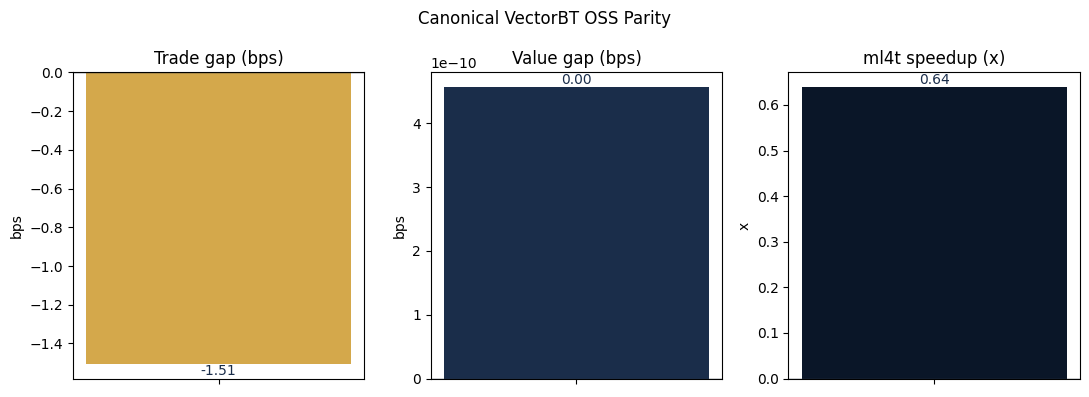

In [13]:
labels = ["Trade gap (bps)", "Value gap (bps)", "ml4t speedup (x)"]
values = [
    row["trade_gap_pct"] * 10_000,
    row["final_value_gap_pct"] * 10_000,
    row["runtime_speedup"],
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
_panel_colors = [COLORS["amber"], COLORS["slate"], COLORS["blue"]]
for ax_i, (lbl, val, color) in enumerate(zip(labels, values, _panel_colors)):
    axes[ax_i].bar([""], [val], color=color, width=0.4)
    axes[ax_i].set_title(lbl)
    axes[ax_i].axhline(0.0, color=COLORS["neutral"], linewidth=1.0)
    axes[ax_i].set_ylabel(lbl.split("(")[-1].rstrip(")") if "(" in lbl else "")
    axes[ax_i].text(
        0,
        val,
        f"{val:.2f}",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontsize=10,
        color=COLORS["slate"],
    )
fig.suptitle("Canonical VectorBT OSS Parity")
fig.tight_layout()
fig.show()

## 7. Interpret the Residual

VectorBT OSS is the cleanest example in the chapter of why "same final PnL"
is not always the same thing as "same trade decomposition."

In [14]:
_gap_direction = "more" if row["trade_gap"] >= 0 else "fewer"
_trade_gap_str = (
    f"{abs(int(row['trade_gap'])):,} {_gap_direction} ml4t trades "
    f"than {int(row['reference_num_trades']):,} benchmark trades"
    f" ({row['trade_gap_pct'] * 10_000:.3f} bps)"
)
interpretation_df = pl.DataFrame(
    {
        "dimension": [
            "execution surface",
            "share model",
            "timing model",
            "economic result",
            "remaining mismatch",
        ],
        "state": [
            "vectorized target-percent orders",
            "fractional shares",
            "same-bar close",
            "exact terminal-value parity",
            _trade_gap_str,
        ],
        "reader_takeaway": [
            "Both engines are operating on a fully vectorized canonical benchmark.",
            "Integer-share rounding is not the dominant issue here.",
            "The calibrated profile is aligned to VectorBT's same-bar close semantics.",
            "The portfolio-level outcome is matched to floating-point noise.",
            "The residual likely reflects order bundling / signal processing edge cases, not economic drift.",
        ],
    }
)
interpretation_df

dimension,state,reader_takeaway
str,str,str
"""execution surface""","""vectorized target-percent orde…","""Both engines are operating on …"
"""share model""","""fractional shares""","""Integer-share rounding is not …"
"""timing model""","""same-bar close""","""The calibrated profile is alig…"
"""economic result""","""exact terminal-value parity""","""The portfolio-level outcome is…"
"""remaining mismatch""","""34 fewer ml4t trades than 225,…","""The residual likely reflects o…"


## Key Takeaways

All numeric claims below are sourced from the loaded payload (`row`) so
they remain consistent with the displayed table.

1. **VectorBT OSS has tight terminal-value parity on the canonical benchmark.**
   The displayed table reports the final-value gap in basis points (the
   `final_value_gap_bps` row).

2. **Trade-count parity is not exact.** The residual trade gap and benchmark
   trade count are printed by the displayed table (`trade_gap` /
   `trade_gap_bps`).

3. **This is still a useful validation result.** It demonstrates that the
   calibrated `vectorbt_strict` profile reproduces the benchmark economics
   even though the exact order decomposition is not fully matched yet.

4. **VectorBT is faster on this benchmark.** Expected: the canonical
   benchmark is highly compatible with a vectorized execution surface, and
   `row['runtime_speedup']` quantifies the speedup for this run.

The committed `resources/vectorbt_parity_results.json` holds the genuine
canonical-benchmark rerun (`ml4t-vbt-strict` vs `vbt-oss` on real
250×20yr daily data). Every claim above is computed from `row`, so setting
`RUN_LIVE = True` refreshes the numbers and the prose stays consistent.

**Next**: [`17_backtrader_zipline_engine_parity`](17_backtrader_zipline_engine_parity.ipynb)
and [`15_lean_engine_parity`](15_lean_engine_parity.ipynb) show the stronger
event-level parity results for the other external engines.

---
*Notebook: 18_vectorbt_engine_parity*
*ML4T 3rd Edition - Chapter 16: Strategy Simulation*